# Task 1 — Ground Level Detection

**Goal:** Find the best value for the ground level in a LiDAR point cloud using a histogram of z-values.

The function `get_ground_level()` should return a z-threshold. All points above this threshold are kept for further processing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Load dataset

Each dataset is a 2D array where each row is a point with `[x, y, z]` values.

In [2]:
pcd1 = np.load("dataset1.npy")
pcd2 = np.load("dataset2.npy")

print("dataset1 shape:", pcd1.shape)
print("dataset2 shape:", pcd2.shape)

dataset1 shape: (72067, 3)
dataset2 shape: (84588, 3)


## Step 1 — Explore the z-values

Before implementing anything, we inspect the distribution of z-values to understand where the ground level sits.

z min: 60.57800000000003
z max: 79.769
z mean: 65.5208586454272


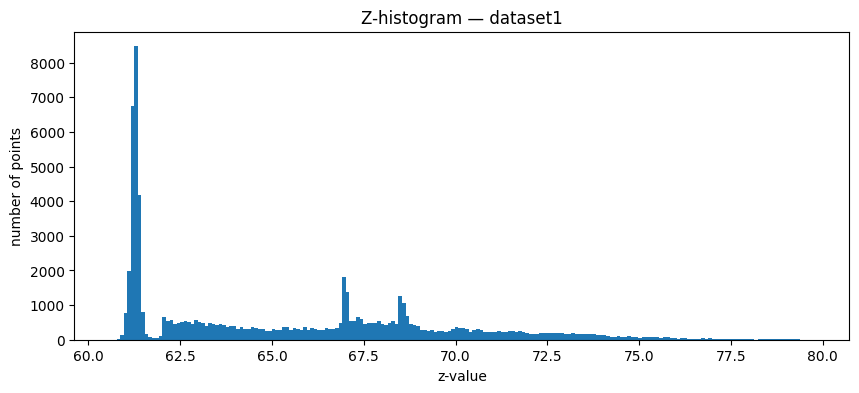

In [3]:
print("z min:", pcd1[:,2].min())
print("z max:", pcd1[:,2].max())
print("z mean:", pcd1[:,2].mean())

plt.figure(figsize=(10, 4))
plt.hist(pcd1[:,2], bins=200)
plt.xlabel("z-value")
plt.ylabel("number of points")
plt.title("Z-histogram — dataset1")
plt.show()

### Observations

The z-values range from 60.58 to 79.77, with a mean of 65.52.
The histogram shows a dominant peak at approximately z is around 61.1, representing the ground plane (track surface). 
This peak contains roughly 8 500 points — the largest concentration in the dataset.

Above z ≈ 62.5 the distribution becomes sparse, with two smaller clusters visible around z like 67 and z like 68, likely corresponding to trackside structures. 
Points above z ≈ 70 are very sparse and likely include the catenary wire.

The sharp, isolated ground peak confirms that a histogram-based approach works wll for detecting the ground level in this dataset.

## Step 2 — Implement get_ground_level()

Use the histogram peak in the z-values to automatically detect the ground level.

In [ ]:
def get_ground_level(pcd):
    counts, bin_edges = np.histogram(pcd[:, 2], bins=200)
    peak_idx = np.argmax(counts)
    ground_level = bin_edges[peak_idx + 1] + 0.5  # right edge of peak bin + 0.5m margin
    return ground_level

print("Ground level dataset1:", get_ground_level(pcd1))
print("Ground level dataset2:", get_ground_level(pcd2))

Ground level dataset1: 61.84564000000003
Ground level dataset2: 61.76545


Both datasets shiws very similar ground levels, and they shoudl; they cover the same railway corridor. 
The small difference likely reflects minor variation along the track.

The threshold is placed at the histogram peak plus a 0.5 m margin, to take into account that sloped or slightly elevated ground surfaces are excluded before clustering.

## Step 3 — Filter ground points and visualize result

Apply `get_ground_level()` to remove ground points, then verify the result visually.

dataset1: 72067 points → 48676 above ground (67.5%)
dataset2: 84588 points → 65608 above ground (77.6%)


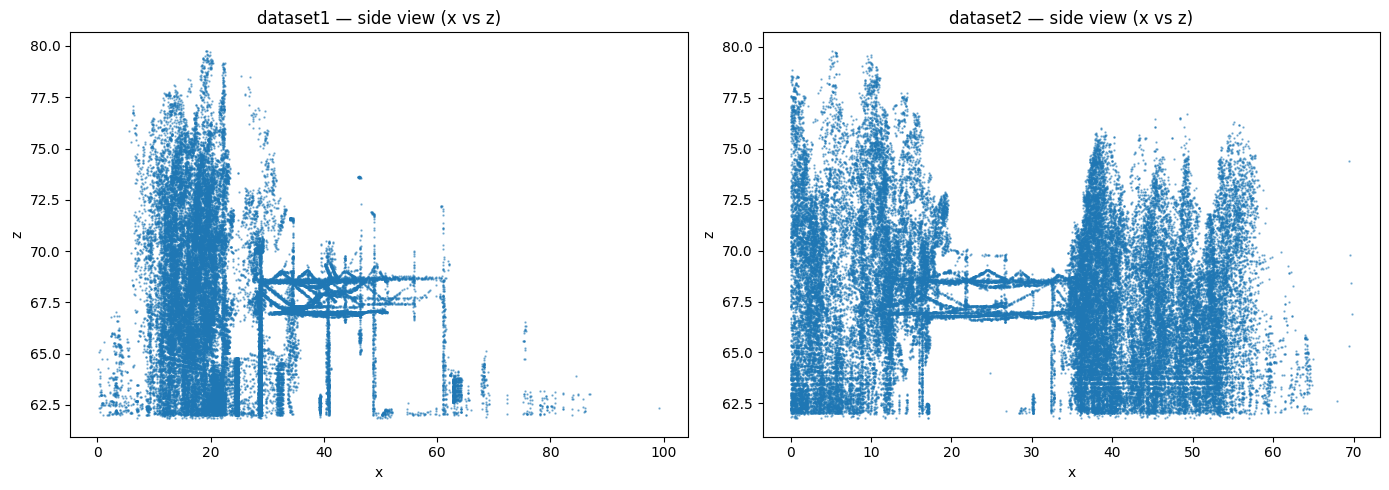

In [5]:
# Apply ground filter to both datasets
ground1 = get_ground_level(pcd1)
ground2 = get_ground_level(pcd2)

pcd1_above = pcd1[pcd1[:, 2] > ground1]
pcd2_above = pcd2[pcd2[:, 2] > ground2]

print(f"dataset1: {len(pcd1)} points → {len(pcd1_above)} above ground ({len(pcd1_above)/len(pcd1)*100:.1f}%)")
print(f"dataset2: {len(pcd2)} points → {len(pcd2_above)} above ground ({len(pcd2_above)/len(pcd2)*100:.1f}%)")

# Side view (x vs z) — shows the vertical structure clearly
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pcd1_above[:, 0], pcd1_above[:, 2], s=0.5, alpha=0.5)
axes[0].set_title("dataset1 — side view (x vs z)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("z")

axes[1].scatter(pcd2_above[:, 0], pcd2_above[:, 2], s=0.5, alpha=0.5)
axes[1].set_title("dataset2 — side view (x vs z)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("z")

plt.tight_layout()
plt.show()